In [1]:
from pathlib import Path
import pydicom
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Preprocess

In [2]:
labels = pd.read_csv("/kaggle/input/rsna-heart-detection/rsna_heart_detection.csv")

In [3]:
labels.head(6)

,label,x0,y0,w,h,name,img_shape_x,img_shape_y
0,heart,91,71,77,102,ca112a3c-b701-48b8-a94f-725ea65416a7,224,224
1,heart,70,64,89,67,e5f292ae-f1e5-497c-b0a0-68f1aa2196b2,224,224
2,heart,82,55,81,76,67af68f7-7ba0-49a0-a373-3a8801eb0faa,224,224
3,heart,93,74,78,89,814289a3-9ce8-4cba-842f-45d6a36f540d,224,224
4,heart,85,61,85,93,e508969f-c931-462b-aa90-ccde34a4d9e5,224,224
5,heart,63,60,100,85,f1e96436-85c2-4179-b7e9-3f3091e29d76,224,224


In [4]:
ROOT_PATH = Path("/kaggle/input/rsna-pneumonia-detection-challenge/stage_2_train_images/")
SAVE_PATH = Path("processed_heart_detection")

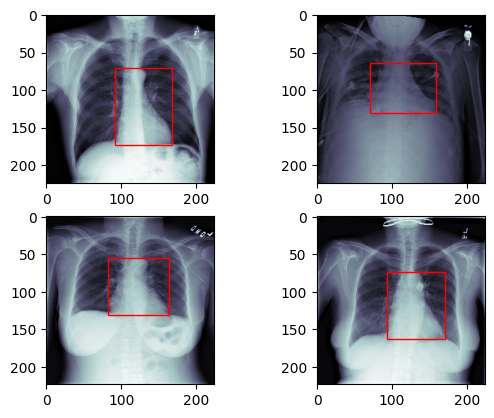

In [5]:
fig, ax = plt.subplots(2,2)
c = 0
for i in range(2):
    for j in range(2):
        data = labels.iloc[c]
        patient_id = labels["name"].iloc[c]
        dcm_path = ROOT_PATH/str(patient_id)
        dcm_path = dcm_path.with_suffix(".dcm")

        dcm = pydicom.dcmread(dcm_path)
        dcm_array = dcm.pixel_array
        dcm_array = cv2.resize(dcm_array, (224, 224))

        x = data["x0"]
        y = data["y0"]
        height = data["h"]
        width = data["w"]

        ax[i][j].imshow(dcm_array, cmap="bone")
        rect = patches.Rectangle((x,y), width, height, linewidth=1, edgecolor="r", facecolor="none")
        ax[i][j].add_patch(rect)
        
        c+=1

In [6]:
sums, sums_squared = 0,0
train_ids = []
val_ids = []

for c, patient_id in enumerate(list(labels.name)):
        patient_id = labels["name"].iloc[c]
        dcm_path = ROOT_PATH/str(patient_id)
        dcm_path = dcm_path.with_suffix(".dcm")

        dcm = pydicom.dcmread(dcm_path)
        dcm_array = dcm.pixel_array
        dcm_array = (cv2.resize(dcm_array, (224, 224)) / 255).astype(np.float16)

        train_or_val = "train" if c < 400 else "val"

        if train_or_val == "train":
            train_ids.append(patient_id)
        else:
            val_ids.append(patient_id)

        current_save_path = SAVE_PATH/train_or_val
        current_save_path.mkdir(parents=True, exist_ok=True)
        np.save(current_save_path/patient_id, dcm_array)

        normalizer = dcm_array.shape[0] * dcm_array.shape[1]
        if train_or_val == "train":
            sums += np.sum(dcm_array) / normalizer
            sums_squared += (np.power(dcm_array, 2).sum()) / normalizer

In [7]:
np.save("processed_heart_detection/train_subjects", train_ids)
np.save("processed_heart_detection/val_subjects", val_ids)

In [8]:
mean = sums/len(train_ids)
std = np.sqrt((sums_squared/len(train_ids)) - mean**2)

In [9]:
mean, std

(0.49431162308673426, 0.2527880419517652)

# Dataset Creation

In [10]:
import torch
import imgaug
from imgaug.augmentables.bbs import BoundingBox

In [11]:
class CardiacDataset(torch.utils.data.Dataset):

    def __init__(self, path_to_labels_csv, patients, root_path, augs):
        
        self.labels = pd.read_csv(path_to_labels_csv)
        
        self.patients = np.load(patients)
        self.root_path = Path(root_path)
        self.augment = augs
        
    def  __len__(self):
        """
        Returns the length of the dataset
        """
        return len(self.patients)
        
    def __getitem__(self, idx):
        """
        Returns an image paired with bbox around the heart
        """
        patient = self.patients[idx]
        # Get data according to index
        data = self.labels[self.labels["name"]==patient]
        
        # Get entries of given patient
        # Extract coordinates
        
        x_min = data["x0"].item()
        y_min = data["y0"].item()
        x_max = x_min + data["w"].item()  # get xmax from width
        y_max = y_min + data["h"].item()  # get ymax from height
        bbox = [x_min, y_min, x_max, y_max]


        # Load file and convert to float32
        file_path = self.root_path/patient  # Create the path to the file
        img = np.load(f"{file_path}.npy").astype(np.float32)
        
        
        # Apply imgaug augmentations to image and bounding box
        if self.augment:
            
            bb = BoundingBox(x1=bbox[0], y1=bbox[1], x2=bbox[2], y2=bbox[3])
            
            ###################IMPORTANT###################
            # Fix for https://discuss.pytorch.org/t/dataloader-workers-generate-the-same-random-augmentations/28830/2
            # https://github.com/pytorch/pytorch/issues/5059
            random_seed = torch.randint(0, 1000000, (1,)).item()
            imgaug.seed(random_seed)
            #####################################################

            img, aug_bbox  = self.augment(image=img, bounding_boxes=bb)
            bbox = aug_bbox[0][0], aug_bbox[0][1], aug_bbox[1][0], aug_bbox[1][1]
            
            
        # Normalize the image according to the values computed in Preprocessing
        img = (img - 0.494) / 0.252

        img = torch.tensor(img).unsqueeze(0)
        bbox = torch.tensor(bbox)
            
        return img, bbox

# Validate functionality

In [12]:
import imgaug.augmenters as iaa
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [13]:
seq = iaa.Sequential([
            iaa.GammaContrast(),
            iaa.Affine(
                scale=(0.8, 1.2),
                rotate=(-10, 10),
                translate_px=(-10, 10)
            )
        ])

In [14]:
labels_path = "/kaggle/input/rsna-heart-detection/rsna_heart_detection.csv"
patients_path = "/kaggle/working/processed_heart_detection/train_subjects.npy"
train_root = "/kaggle/working/processed_heart_detection/train/"
dataset = CardiacDataset(labels_path, patients_path, train_root, seq)

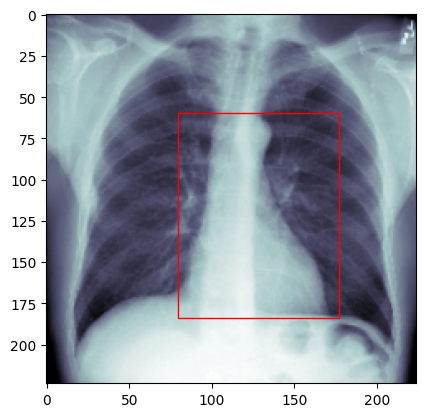

In [15]:
img, bbox = dataset[0]

fig, axis = plt.subplots(1, 1)
axis.imshow(img[0], cmap="bone")
rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2]-bbox[0], bbox[3]-bbox[1], edgecolor="r", facecolor="none")
axis.add_patch(rect)

# Data loading

In [16]:
from torchvision import transforms
import torchvision
import torch
import torchmetrics
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
import os

In [17]:
train_root_path = "/kaggle/working/processed_heart_detection/train/"
train_subjects = "/kaggle/working/processed_heart_detection/train_subjects.npy"
val_root_path = "/kaggle/working/processed_heart_detection/val/"
val_subjects = "/kaggle/working/processed_heart_detection/val_subjects.npy"

In [18]:
train_transforms = iaa.Sequential([
            iaa.GammaContrast(),
            iaa.Affine(
                scale=(0.8, 1.2),
                rotate=(-10, 10),
                translate_px=(-10, 10)
            )
        ])

In [19]:
train_dataset = CardiacDataset(labels_path, train_subjects, train_root_path, train_transforms)
val_dataset = CardiacDataset(labels_path, val_subjects, val_root_path, None)

In [20]:
batch_size = 8
num_workers = os.cpu_count()

train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    num_workers=num_workers,
    shuffle=True)

val_loader = torch.utils.data.DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    num_workers=num_workers,
    shuffle=False)

# Model creation

In [21]:
class CardiacDetectionModel(pl.LightningModule):
    def __init__(self):
        super().__init__()
        
        self.model = torchvision.models.resnet18(pretrained=True)
        
        # Change conv1 from 3 to 1 input channels
        self.model.conv1 = torch.nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        
        # Change out_feature of the last fully connected layer (called fc in resnet18) from 1000 to 4
        self.model.fc = torch.nn.Linear(in_features=512, out_features=4)
        
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-4)
        self.loss_fn = torch.nn.MSELoss()
    
    def forward(self, data):
        pred = self.model(data)
        return pred
    
    def training_step(self, batch, batch_idx):
        x_ray, label = batch
        label = label.float()  # Convert label to float (just needed for loss computation)
        pred = self(x_ray)
        loss = self.loss_fn(pred, label)  # Compute the loss
        
        # Log loss
        self.log("Train Loss", loss)
        if batch_idx % 50 == 0:
            self.log_images(x_ray.cpu(), pred.cpu(), label.cpu(), "Train")

        return loss
    
        
    def validation_step(self, batch, batch_idx):
        # Same steps as in the training_step
        x_ray, label = batch
        label = label

        label = label.float()  # Convert label to float (just needed for loss computation)
        pred = self(x_ray)
        
        loss = self.loss_fn(pred, label)
        self.log("Val Loss", loss)
        if batch_idx % 50 == 0:
            self.log_images(x_ray.cpu(), pred.cpu(), label.cpu(), "Val")
        return loss
    
    def log_images(self, x_ray, pred, label, name):
        results = []
        
        # Here we create a grid consisting of 4 predictions
        for i in range(4):
            coords_labels = label[i]
            coords_pred = pred[i]
            img = ((x_ray[i] * 0.252)+0.494).numpy()[0]
            
            # Extract the coordinates from the label
            x0, y0 = coords_labels[0].int().item(), coords_labels[1].int().item()
            x1, y1 = coords_labels[2].int().item(), coords_labels[3].int().item()
            img = cv2.rectangle(img, (x0, y0), (x1, y1), (0, 0, 0), 2)
            
            # Extract the coordinates from the prediction           
            x0, y0 = coords_pred[0].int().item(), coords_pred[1].int().item()
            x1, y1 = coords_pred[2].int().item(), coords_pred[3].int().item()
            img = cv2.rectangle(img, (x0, y0), (x1, y1), (1, 1, 1), 2)
            
            
            results.append(torch.tensor(img).unsqueeze(0))
        grid = torchvision.utils.make_grid(results, 2)
        self.logger.experiment.add_image(f"{name} Prediction vs Label", grid, self.global_step)

            
    
    def configure_optimizers(self):
        # Caution! Alwayus has to be a list
        return [self.optimizer]

In [22]:
model = CardiacDetectionModel()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 213MB/s]


In [23]:
checkpoint_callback = ModelCheckpoint(
    monitor='Val Loss',
    save_top_k=10,
    dirpath='./checkpoints',
    mode='min')

In [24]:
trainer = pl.Trainer(logger=TensorBoardLogger("/kaggle/working/logs"), log_every_n_steps=1,
                     default_root_dir="/kaggle/working/weights", callbacks=checkpoint_callback,
                     max_epochs=100)

In [25]:
trainer.fit(model, train_loader, val_loader)

2025-05-03 22:00:37.253179: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746309637.440529      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746309637.496339      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [26]:
!ls ./checkpoints

'epoch=77-step=3900.ckpt'  'epoch=88-step=4450.ckpt'  'epoch=97-step=4900.ckpt'
'epoch=80-step=4050.ckpt'  'epoch=90-step=4550.ckpt'  'epoch=98-step=4950.ckpt'
'epoch=84-step=4250.ckpt'  'epoch=91-step=4600.ckpt'
'epoch=87-step=4400.ckpt'  'epoch=96-step=4850.ckpt'


# Evaluation

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [28]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = CardiacDetectionModel.load_from_checkpoint("./checkpoints/epoch=98-step=4950.ckpt")
model.eval();
model.to(device);

In [29]:
preds = []
labels = []

with torch.no_grad():
    for data, label in val_dataset:
        data = data.to(device).float().unsqueeze(0)
        pred = model(data)[0].cpu()
        preds.append(pred)
        labels.append(label)
        
preds=torch.stack(preds)
labels=torch.stack(labels)

In [30]:
abs(preds-labels).mean(0)

tensor([3.8895, 4.0828, 5.6009, 6.2198])

tensor([ 96,  62, 172, 147])


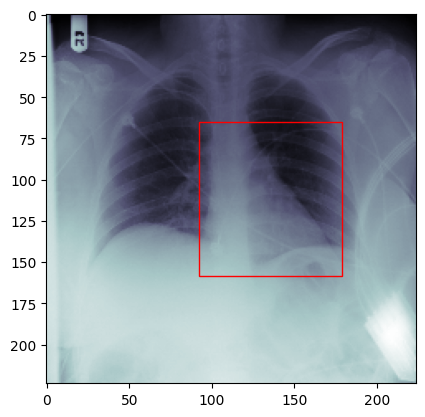

In [31]:
IDX = 95
img, label = val_dataset[IDX]
current_pred = preds[IDX]

fig, axis = plt.subplots(1, 1)
axis.imshow(img[0], cmap="bone")
heart = patches.Rectangle((current_pred[0], current_pred[1]), current_pred[2]-current_pred[0],
                          current_pred[3]-current_pred[1], linewidth=1, edgecolor='r', facecolor='none')
axis.add_patch(heart)

print(label)

In [32]:
def compute_iou(box1, box2):
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    inter_area = max(0, xB - xA) * max(0, yB - yA)

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    iou = inter_area / float(box1_area + box2_area - inter_area + 1e-6)
    return iou

In [33]:
ious = [compute_iou(p, l) for p, l in zip(preds, labels)]
mean_iou = sum(ious) / len(ious)
print(f"Intersection over Union value: {round(mean_iou.item(),2)}")

Intersection over Union value: 0.81
